In [110]:
# 셀 1: 라이브러리 & 설정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, GRU, Conv1D
)
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from lime.lime_text import LimeTextExplainer
import os, pickle

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

MAX_WORDS  = 2000
MAX_LEN    = 30
EMBED_DIM  = 64
EPOCHS     = 50
BATCH_SIZE = 32
DATA_PATH  = './data/GeoPulse_Final_Dataset_KOREAN.csv'

os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)
print('✅ 환경 설정 완료')

✅ 환경 설정 완료


In [111]:
# 셀 2: 데이터 전처리 클래스
#   make_text_cause() → 원인 분류용 
#   make_text_risk()  → 강도 분류용 

class ConflictDataProcessor:
    def __init__(self, data_path: str):
        self.data_path       = data_path
        self.df              = None
        self.tokenizer_cause = None
        self.tokenizer_risk  = None
        self.cause_map = {'영토': 0, '정부/권력': 1, '복합': 2}
        self.risk_map  = {'소규모': 0, '전면전': 1}
        self.cause_rev = {v: k for k, v in self.cause_map.items()}
        self.risk_rev  = {v: k for k, v in self.risk_map.items()}

    def load(self):
        self.df = pd.read_csv(self.data_path)
        self.df = self.df.dropna(subset=['분쟁원인', '전쟁강도'])
        self.df['사망자_추정치'] = self.df['사망자_추정치'].fillna(0)
        print(f'✅ 데이터 로드: {len(self.df)}행')
        print(f'   전쟁강도 분포: {dict(self.df["전쟁강도"].value_counts())}')
        return self.df

    def make_text_cause(self, row):
        """원인 분류용 텍스트 (기존과 동일)"""
        parts = [
            str(row.get('발생지', '')),
            str(row.get('정부군(교전A)', '')),
            str(row.get('반군/적대측(교전B)', '')),
            str(row.get('분쟁유형', '')),
        ]
        return ' '.join(p for p in parts if p not in ('', 'nan'))

    def make_text_risk(self, row):
        
        parts = [
            str(row.get('발생지', '')),
            str(row.get('정부군(교전A)', '')),
            str(row.get('반군/적대측(교전B)', '')),
            str(row.get('분쟁유형', '')),
            str(row.get('분쟁원인', '')),
        ]
        return ' '.join(p for p in parts if p not in ('', 'nan'))

    def preprocess(self):
        self.df['text_cause'] = self.df.apply(self.make_text_cause, axis=1)
        self.df['text_risk']  = self.df.apply(self.make_text_risk,  axis=1)

        self.tokenizer_cause = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
        self.tokenizer_cause.fit_on_texts(self.df['text_cause'])
        seqs_c  = self.tokenizer_cause.texts_to_sequences(self.df['text_cause'])
        X_cause = pad_sequences(seqs_c, maxlen=MAX_LEN, padding='post')

        self.tokenizer_risk = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
        self.tokenizer_risk.fit_on_texts(self.df['text_risk'])
        seqs_r = self.tokenizer_risk.texts_to_sequences(self.df['text_risk'])
        X_risk = pad_sequences(seqs_r, maxlen=MAX_LEN, padding='post')

        y_cause = self.df['분쟁원인'].map(self.cause_map).values
        y_risk  = self.df['전쟁강도'].map(self.risk_map).values

        print(f'✅ 전처리 완료 | X_cause: {X_cause.shape} | X_risk: {X_risk.shape}')
        return X_cause, X_risk, y_cause, y_risk

    def split(self, X, y, test_size=0.2):
        return train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

print('✅ ConflictDataProcessor 정의 완료')

✅ ConflictDataProcessor 정의 완료


In [112]:
# 셀 3: DL 모델 클래스 (class_weight 파라미터 추가)
class ConflictClassifier:
    def __init__(self, num_classes, name):
        self.num_classes = num_classes
        self.name        = name
        self.model       = None
        self.history     = None

    def build(self, model_type='baseline'):
        self.model = Sequential(name=f'{self.name}_{model_type}')
        self.model.add(Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM,
                                 input_length=MAX_LEN))
        if model_type == 'baseline':
            self.model.add(GlobalAveragePooling1D())
        elif model_type == 'cnn':
            self.model.add(Conv1D(64, 3, padding='valid', activation='relu'))
            self.model.add(GlobalMaxPooling1D())
        elif model_type == 'gru':
            self.model.add(Bidirectional(GRU(64, return_sequences=False)))

        self.model.add(Dense(64, activation='relu'))
        self.model.add(Dropout(0.4))
        self.model.add(Dense(self.num_classes, activation='softmax'))
        self.model.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])
        self.model.summary()
        return self.model

    def train(self, X_train, y_train, X_val, y_val, class_weight=None):
        """class_weight: 불균형 데이터 보정 (강도 분류기에서 사용)"""
        callbacks = [EarlyStopping(monitor='val_accuracy', patience=5,
                                   restore_best_weights=True, verbose=1)]
        self.history = self.model.fit(
            X_train, y_train, validation_data=(X_val, y_val),
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            callbacks=callbacks, class_weight=class_weight, verbose=1
        )
        return self.history

    def evaluate(self, X_test, y_test, label_names):
        loss, acc = self.model.evaluate(X_test, y_test, verbose=0)
        print(f'\n📊 [{self.name}] 정확도: {acc*100:.2f}%  |  손실: {loss:.4f}')
        y_pred = np.argmax(self.model.predict(X_test, verbose=0), axis=1)
        print(classification_report(y_test, y_pred, target_names=label_names))
        return y_pred

    def predict_one(self, text, tokenizer, label_map):
        seq    = tokenizer.texts_to_sequences([text])
        padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
        probs  = self.model.predict(padded, verbose=0)[0]
        idx    = int(np.argmax(probs))
        return {'label': label_map[idx], 'confidence': float(probs[idx]),
                'probs': {label_map[i]: float(p) for i, p in enumerate(probs)}}

    def save(self, path):
        self.model.save(path)
        print(f'✅ 저장: {path}')

print('✅ ConflictClassifier 정의 완료')

✅ ConflictClassifier 정의 완료


In [ ]:
# ============================================================
# 셀 4: 시각화 클래스
# 초심자 핵심: PPT/발표용 그래프 뽑아주는 도구
# plots/ 폴더에 자동 저장됨
# ============================================================
class Visualizer:

    @staticmethod
    def plot_data_distribution(df: pd.DataFrame, save_path='plots'):
        """PPT용 - 데이터 분포 (분쟁원인/강도/유형)"""
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle('데이터셋 분포 (1989~2024)',
                     fontsize=16, fontweight='bold')
        cols   = ['분쟁원인', '전쟁강도', '분쟁유형']
        colors = ['#065A82', '#1C7293', '#21295C']
        for ax, col, color in zip(axes, cols, colors):
            counts = df[col].value_counts()
            bars   = ax.bar(counts.index, counts.values,
                            color=color, alpha=0.85)
            ax.set_title(col, fontsize=13, fontweight='bold')
            ax.set_ylabel('건수')
            ax.spines[['top','right']].set_visible(False)
            for bar, v in zip(bars, counts.values):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 5, str(v),
                        ha='center', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{save_path}/data_distribution.png', dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_yearly_trend(df: pd.DataFrame, save_path='plots'):
        """PPT용 - 연도별 분쟁 발생 추이"""
        yearly = df.groupby('연도').size().reset_index(name='건수')
        fig, ax = plt.subplots(figsize=(13, 4))
        ax.fill_between(yearly['연도'], yearly['건수'],
                        alpha=0.25, color='#065A82')
        ax.plot(yearly['연도'], yearly['건수'],
                color='#065A82', linewidth=2.5, marker='o', markersize=3)
        peak = yearly.loc[yearly['건수'].idxmax()]
        ax.annotate(
            f"최고 {int(peak['건수'])}건\n({int(peak['연도'])})",
            xy=(peak['연도'], peak['건수']),
            xytext=(peak['연도']+1, peak['건수']+3),
            fontsize=10, color='#F96167',
            arrowprops=dict(arrowstyle='->', color='#F96167')
        )
        ax.set_title('연도별 전 세계 분쟁 발생 건수 (1989~2024)',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('연도'); ax.set_ylabel('건수')
        ax.spines[['top','right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(f'{save_path}/yearly_trend.png', dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_training_history(history, model_name: str, save_path='plots'):
        """학습 곡선 (정확도 & 손실)"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f'{model_name} 학습 곡선', fontsize=14, fontweight='bold')
        ax1.plot(history.history['accuracy'],     label='훈련', color='#065A82', linewidth=2)
        ax1.plot(history.history['val_accuracy'], label='검증', color='#F96167', linewidth=2, linestyle='--')
        ax1.set_title('정확도'); ax1.legend(); ax1.spines[['top','right']].set_visible(False)
        ax2.plot(history.history['loss'],     label='훈련', color='#065A82', linewidth=2)
        ax2.plot(history.history['val_loss'], label='검증', color='#F96167', linewidth=2, linestyle='--')
        ax2.set_title('손실'); ax2.legend(); ax2.spines[['top','right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(f'{save_path}/{model_name}_history.png', dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_confusion_matrix(y_true, y_pred, labels: list,
                               model_name: str, save_path='plots'):
        """혼동 행렬"""
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels)
        plt.title(f'{model_name} 혼동 행렬', fontsize=13, fontweight='bold')
        plt.ylabel('실제'); plt.xlabel('예측')
        plt.tight_layout()
        plt.savefig(f'{save_path}/{model_name}_confusion.png', dpi=150, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_model_comparison(comp_df: pd.DataFrame, save_path='plots'):
        """PPT 핵심 - 모델 선정 근거 비교 그래프"""
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(comp_df)); width = 0.3
        bars1 = ax.bar(x - width, comp_df['Accuracy'], width,
                       label='정확도 (Acc)', color='#065A82', alpha=0.85)
        bars2 = ax.bar(x,          comp_df['Recall'],   width,
                       label='재현율 (Recall)', color='#F96167', alpha=0.85)
        # 최고 정확도 강조
        best_idx = comp_df['Accuracy'].idxmax()
        # 값 표시
        for bar in bars1:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
        for bar in bars2:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{bar.get_height():.1f}%', ha='center', fontsize=10,
                    fontweight='bold', color='#F96167')
        ax.set_xticks(x - width/2)
        ax.set_xticklabels(comp_df['Model'].str.upper(), fontsize=12, fontweight='bold')
        ax.set_title('[모델 선정 근거] 아키텍처별 성능 비교',
                     fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel('지표 (%)'); ax.set_ylim(0, 115); ax.legend(fontsize=11)
        ax.spines[['top','right']].set_visible(False)
        best_model = comp_df.loc[best_idx, 'Model'].upper()
        plt.tight_layout()
        plt.savefig(f'{save_path}/model_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()

print('✅ Visualizer 정의 완료')

✅ Visualizer 정의 완료


In [114]:
# ============================================================
# 셀 5: 데이터 로드 & 시각화
# 초심자 핵심: df.head()로 데이터 잘 들어왔는지 눈으로 꼭 확인!
# ============================================================
processor = ConflictDataProcessor(DATA_PATH)
df = processor.load()
viz       = Visualizer()

print('\n📊 데이터 샘플:')
df.head()

✅ 데이터 로드: 1586행
   전쟁강도 분포: {'소규모': 1273, '전면전': 313}

📊 데이터 샘플:


,분쟁ID,연도,발생지,정부군(교전A),반군/적대측(교전B),분쟁원인,전쟁강도,분쟁유형,지역,사망자_추정치
0,11342,2012,인도,인도 정부,GNLA,영토,소규모,내전,NaN,27
1,11342,2014,인도,인도 정부,GNLA,영토,소규모,내전,NaN,26
2,11344,2011,수단,수단 정부,Republic of South Sudan,영토,소규모,내전,NaN,145
3,11345,2011,남수단,남수단 정부,"SSDM/A, SSLM/A",정부/권력,소규모,내전,NaN,216
4,11345,2012,남수단,남수단 정부,SSLM/A,정부/권력,소규모,내전,NaN,137


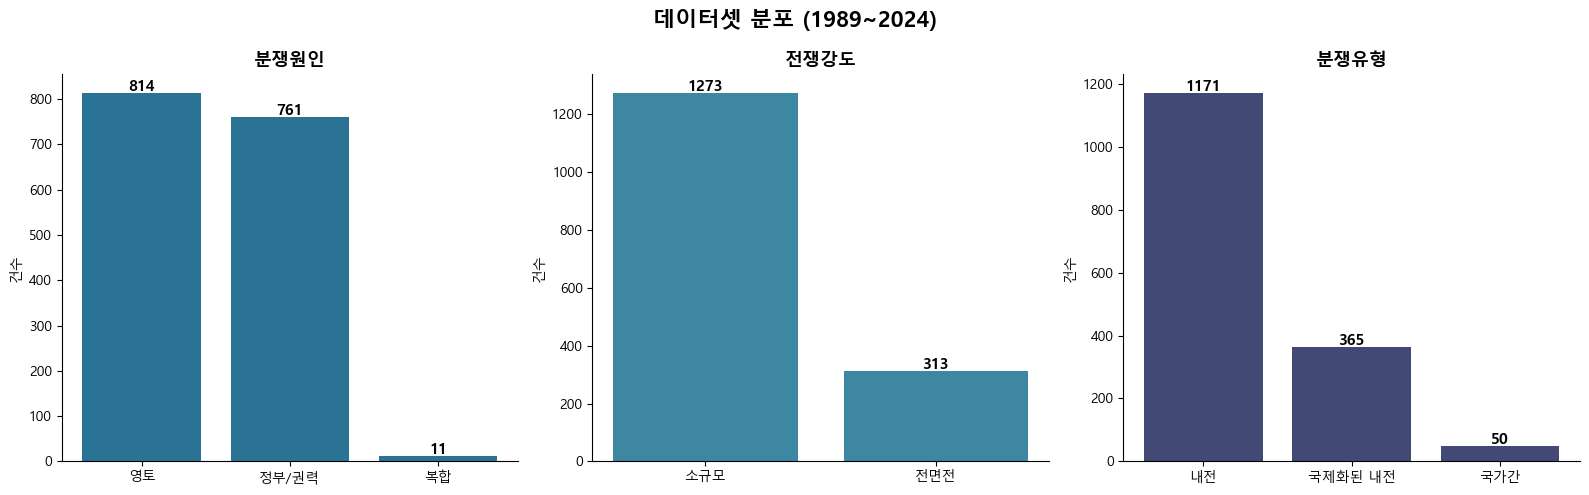

In [115]:
# ============================================================
# 셀 6: PPT용 그래프 1 - 데이터 분포
# ============================================================
viz.plot_data_distribution(df)

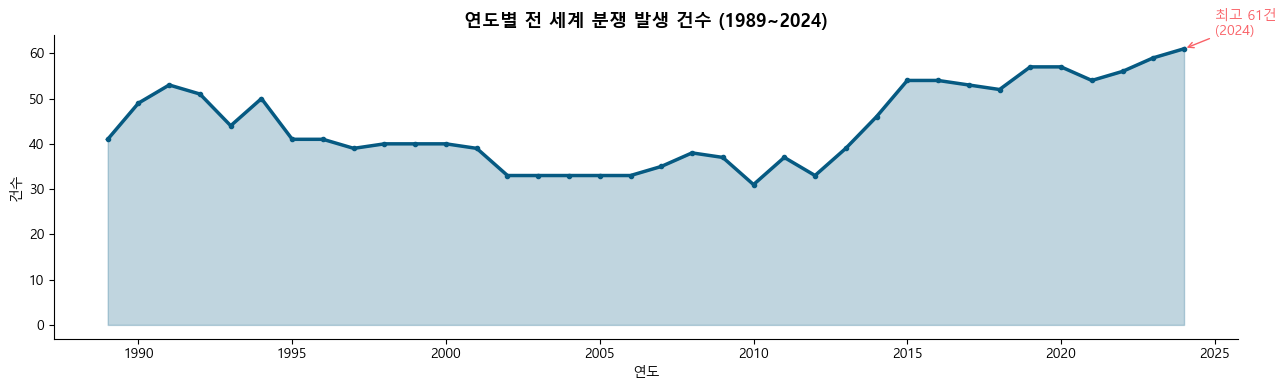

In [116]:
# ============================================================
# 셀 7: PPT용 그래프 2 - 연도별 분쟁 추이
# ============================================================
viz.plot_yearly_trend(df)

In [117]:
# 셀 8: 전처리 & class_weight 계산
X_cause, X_risk, y_cause, y_risk = processor.preprocess()

# 강도 불균형 자동 보정
risk_weights      = compute_class_weight('balanced', classes=np.unique(y_risk), y=y_risk)
risk_class_weight = dict(enumerate(risk_weights))

print(f'\n⚖️ 강도 분류기 class_weight (자동 계산):')
print(f'   소규모(0): {risk_class_weight[0]:.3f}')
print(f'   전면전(1): {risk_class_weight[1]:.3f}')
print(f'   → 전면전을 {risk_class_weight[1]/risk_class_weight[0]:.1f}배 더 중요하게 학습!')

✅ 전처리 완료 | X_cause: (1586, 30) | X_risk: (1586, 30)

⚖️ 강도 분류기 class_weight (자동 계산):
   소규모(0): 0.623
   전면전(1): 2.534
   → 전면전을 4.1배 더 중요하게 학습!


In [118]:
# 셀 9: 원인 분류기 학습
print('='*50)
print('1. 분쟁원인 분류기 (영토 / 정부권력 / 복합)')
print('='*50)

X_tr_c, X_te_c, yc_tr, yc_te = processor.split(X_cause, y_cause)
cause_clf = ConflictClassifier(num_classes=3, name='cause_classifier')
cause_clf.build(model_type='cnn')
cause_clf.train(X_tr_c, yc_tr, X_te_c, yc_te)  # class_weight 없음

1. 분쟁원인 분류기 (영토 / 정부권력 / 복합)
Model: "cause_classifier_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_36 (Embedding)    (None, 30, 64)            128000    
                                                                 
 conv1d_15 (Conv1D)          (None, 28, 64)            12352     
                                                                 
 global_max_pooling1d_15 (G  (None, 64)                0         
 lobalMaxPooling1D)                                              
                                                                 
 dense_72 (Dense)            (None, 64)                4160      
                                                                 
 dropout_36 (Dropout)        (None, 64)                0         
                                                                 
 dense_73 (Dense)            (None, 3)                 195       
                 


📊 [cause_classifier] 정확도: 98.11%  |  손실: 0.0776
              precision    recall  f1-score   support

          영토       0.99      0.98      0.98       163
       정부/권력       0.97      0.99      0.98       153
          복합       1.00      1.00      1.00         2

    accuracy                           0.98       318
   macro avg       0.99      0.99      0.99       318
weighted avg       0.98      0.98      0.98       318



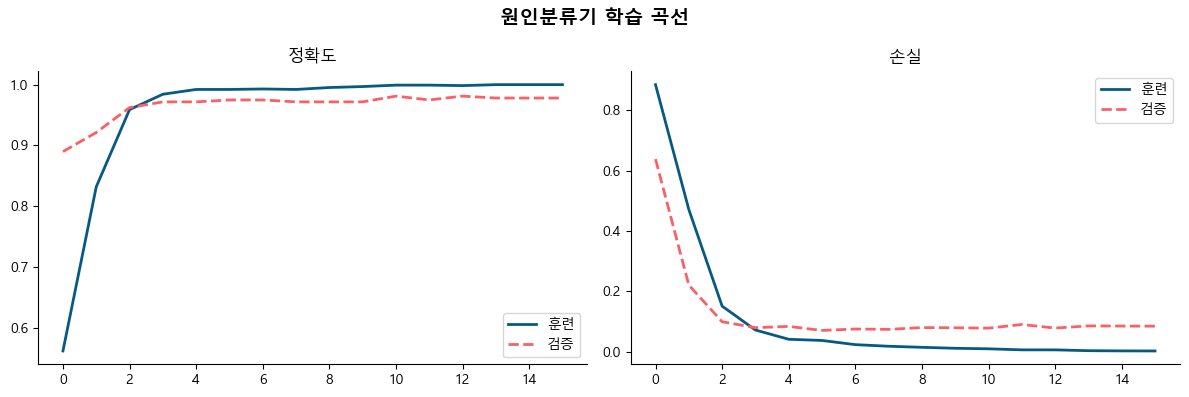

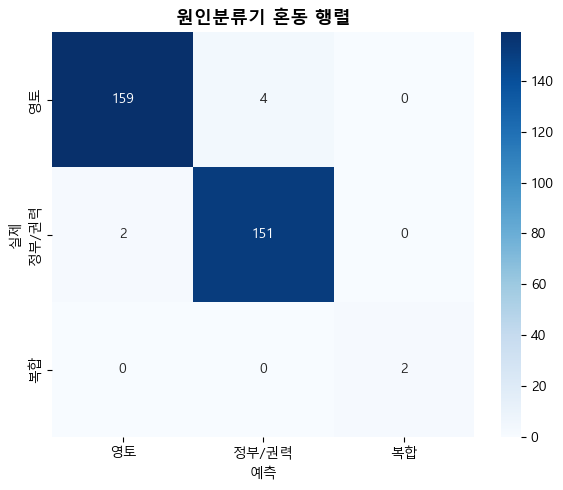

✅ 저장: models/cause_classifier.keras


In [119]:
# ============================================================
# 셀 10: 원인 분류기 평가 & 그래프
# ============================================================
yc_pred = cause_clf.evaluate(X_te_c, yc_te, ['영토', '정부/권력', '복합'])
viz.plot_training_history(cause_clf.history, '원인분류기')
viz.plot_confusion_matrix(yc_te, yc_pred, ['영토', '정부/권력', '복합'], '원인분류기')
cause_clf.save('models/cause_classifier.keras')

In [120]:
# 셀 11: 강도 분류기 학습
#
# 수정 포인트:
#   X_risk (사망자 토큰 포함) + class_weight 적용
#   → 전면전 재현율이 크게 올라야 정상

print('='*50)
print('2. 전쟁강도 분류기')
print('   - 사망자_추정치 피처 추가')
print('   - class_weight 불균형 보정')
print('='*50)

X_tr_r, X_te_r, yr_tr, yr_te = processor.split(X_risk, y_risk)
risk_clf = ConflictClassifier(num_classes=2, name='risk_classifier')
risk_clf.build(model_type='cnn')
risk_clf.train(
    X_tr_r, yr_tr, X_te_r, yr_te,
    class_weight=risk_class_weight  # ← 핵심!
)

# 학습 끝난 risk_clf로 예측할 때, predict_classes 말고 확률(predict)을 뽑는다.
probs = risk_clf.model.predict(X_te_r, verbose=0)

# 전면전(클래스 1)일 확률이 30%(0.3)만 넘어도 무조건 전면전으로 예측하게 룰 변경
custom_threshold = 0.3 
y_pred_custom = (probs[:, 1] > custom_threshold).astype(int)

print("\n🔥 임계값 0.3 적용 시 평가 결과 🔥")
print(classification_report(yr_te, y_pred_custom, target_names=['소규모', '전면전']))

2. 전쟁강도 분류기
   - 사망자_추정치 피처 추가
   - class_weight 불균형 보정
Model: "risk_classifier_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_37 (Embedding)    (None, 30, 64)            128000    
                                                                 
 conv1d_16 (Conv1D)          (None, 28, 64)            12352     
                                                                 
 global_max_pooling1d_16 (G  (None, 64)                0         
 lobalMaxPooling1D)                                              
                                                                 
 dense_74 (Dense)            (None, 64)                4160      
                                                                 
 dropout_37 (Dropout)        (None, 64)                0         
                                                                 
 dense_75 (Dense)            (None, 2)                 13


📊 [risk_classifier] 정확도: 86.16%  |  손실: 0.3831
              precision    recall  f1-score   support

         소규모       0.94      0.88      0.91       255
         전면전       0.62      0.78      0.69        63

    accuracy                           0.86       318
   macro avg       0.78      0.83      0.80       318
weighted avg       0.88      0.86      0.87       318



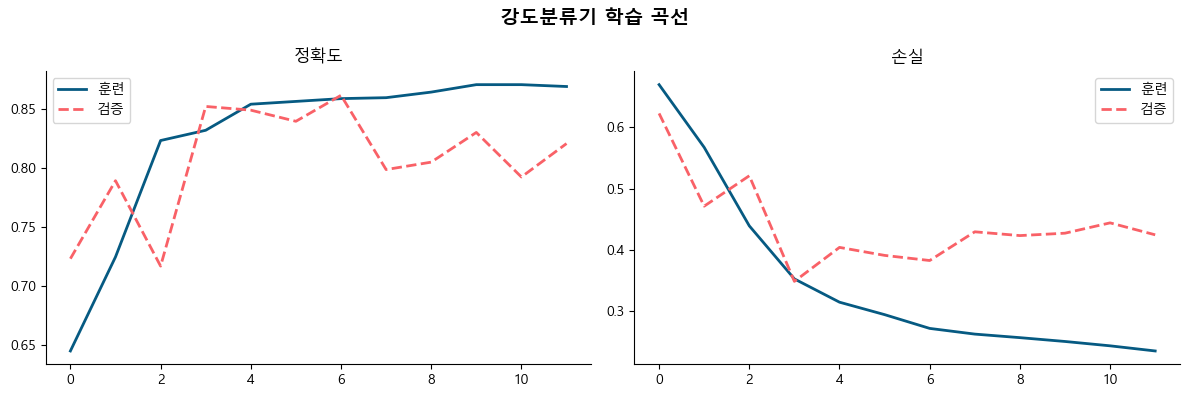

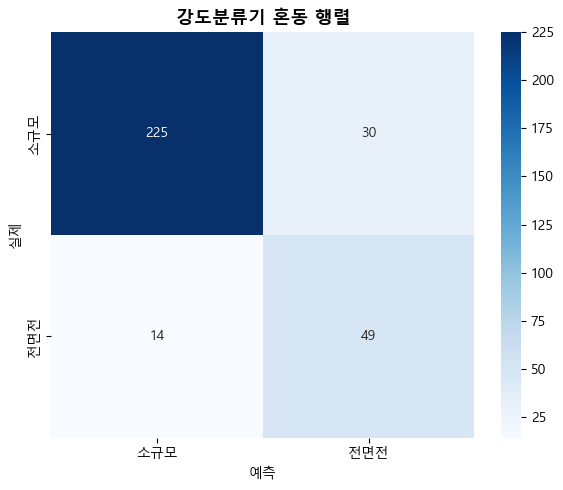

✅ 저장: models/risk_classifier.keras


In [121]:
# ============================================================
# 셀 12: 강도 분류기 평가 & 그래프
# ============================================================
yr_pred = risk_clf.evaluate(X_te_r, yr_te, ['소규모', '전면전'])
viz.plot_training_history(risk_clf.history, '강도분류기')
viz.plot_confusion_matrix(yr_te, yr_pred, ['소규모', '전면전'], '강도분류기')
risk_clf.save('models/risk_classifier.keras')

In [122]:
# ============================================================
# 셀 추가: 강도 분류기 아키텍처 비교 (Baseline vs CNN vs GRU)
# ============================================================
print('🚀 강도 분류기 모델 비교 시작...')
risk_comparison_results = []

for m_type in ['baseline', 'cnn', 'gru']:
    print(f'\n--- {m_type.upper()} 학습 중 ---')
    clf = ConflictClassifier(num_classes=2, name=f'risk_{m_type}')
    clf.build(model_type=m_type)
    clf.train(
        X_tr_r, yr_tr, X_te_r, yr_te,
        class_weight=risk_class_weight  # 불균형 보정
    )
    loss, acc = clf.model.evaluate(X_te_r, yr_te, verbose=0)
    y_pred    = np.argmax(clf.model.predict(X_te_r, verbose=0), axis=1)
    rec       = recall_score(yr_te, y_pred, average='macro')
    risk_comparison_results.append({
        'Model': m_type, 'Accuracy': acc*100,
        'Recall': rec*100, 'Loss': loss
    })

risk_comparison_df = pd.DataFrame(risk_comparison_results)
print('\n✅ 강도 분류기 비교 결과:')
risk_comparison_df

🚀 강도 분류기 모델 비교 시작...

--- BASELINE 학습 중 ---
Model: "risk_baseline_baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_38 (Embedding)    (None, 30, 64)            128000    
                                                                 
 global_average_pooling1d_1  (None, 64)                0         
 0 (GlobalAveragePooling1D)                                      
                                                                 
 dense_76 (Dense)            (None, 64)                4160      
                                                                 
 dropout_38 (Dropout)        (None, 64)                0         
                                                                 
 dense_77 (Dense)            (None, 2)                 130       
                                                                 
Total params: 132290 (516.76 KB)
Trainable params: 132290 (516.76 

,Model,Accuracy,Recall,Loss
0,baseline,80.188680,61.353875,0.683031
1,cnn,83.962262,79.243697,0.403714
2,gru,81.446540,61.540616,0.558187


TypeError: Axes.text() missing 1 required positional argument: 's'

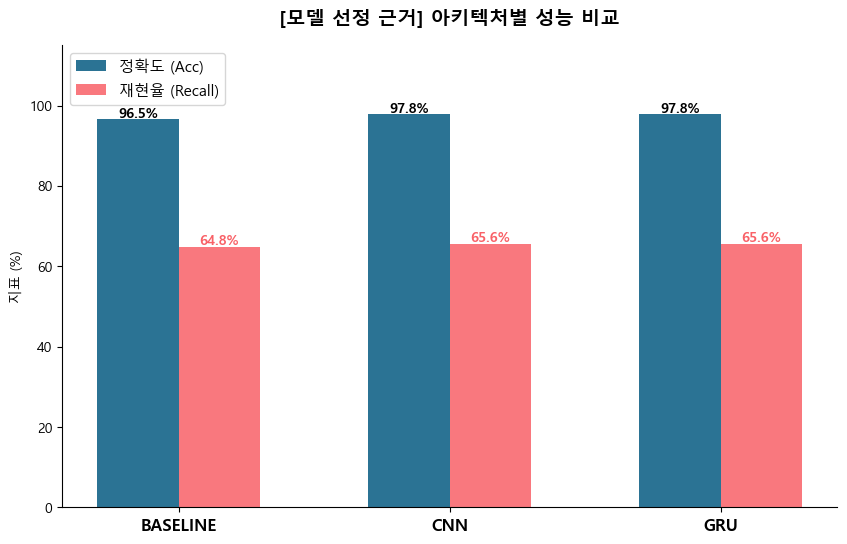

In [123]:
# ============================================================
# 셀 14: PPT용 그래프 3 - 모델 선정 근거
# ============================================================
viz.plot_model_comparison(comparison_df)

TypeError: Axes.text() missing 1 required positional argument: 's'

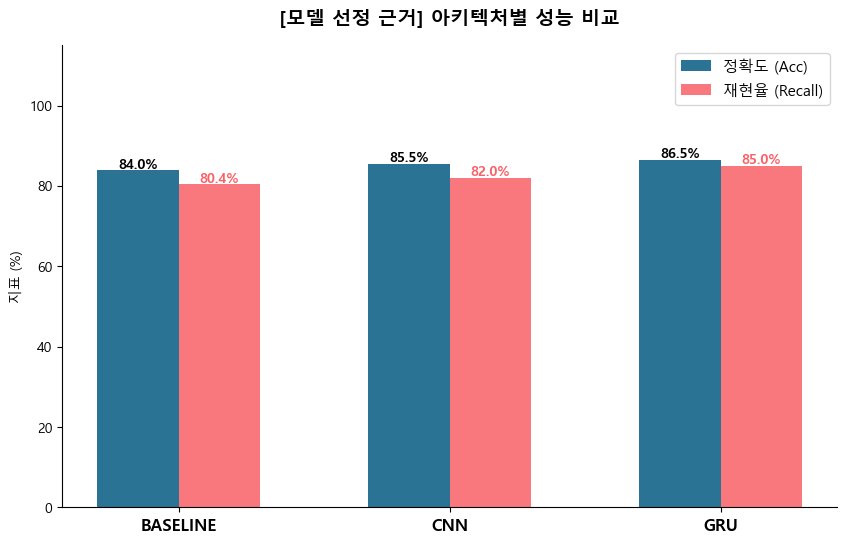

In [ ]:
# 강도 분류기 비교 그래프
viz.plot_model_comparison(risk_comparison_df)
plt.savefig('plots/risk_model_comparison.png', 
            dpi=150, bbox_inches='tight')

In [ ]:
# ============================================================
# 셀 15: 토크나이저 저장 & 예측 테스트
# ============================================================
# 토크나이저 저장
with open('models/tokenizer_cause.pkl', 'wb') as f:
    pickle.dump(processor.tokenizer_cause, f)
with open('models/tokenizer_risk.pkl', 'wb') as f:
    pickle.dump(processor.tokenizer_risk, f)
# app.py 호환용
with open('models/tokenizer.pkl', 'wb') as f:
    pickle.dump(processor.tokenizer_cause, f)
print('✅ 토크나이저 저장: models/tokenizer.pkl')

# 저장된 모델 안전하게 로드 (비교 루프로 덮어써진 변수 방지)
cause_clf_final = ConflictClassifier(num_classes=3, name='cause_final')
cause_clf_final.model = load_model('models/cause_classifier.keras')

risk_clf_final = ConflictClassifier(num_classes=2, name='risk_final')
risk_clf_final.model = load_model('models/risk_classifier.keras')

# 예측 테스트
test_cases = [
    '러시아 지역에서 러시아 정부 대 우크라이나 반군 간의 충돌',
    '시리아 내전 정부군 반군 이념 종교',
    '인도 파키스탄 카슈미르 영토 분쟁',
]

print('\n' + '='*50)
print('🔍 예측 테스트')
print('='*50)

for text in test_cases:
    c = cause_clf_final.predict_one(text, processor.tokenizer_cause, processor.cause_rev)
    r = risk_clf_final.predict_one(text, processor.tokenizer_risk, processor.risk_rev)
    print(f'\n📌 입력: {text}')
    print(f'   원인: {c["label"]} ({c["confidence"]*100:.1f}%)')
    print(f'   강도: {r["label"]} ({r["confidence"]*100:.1f}%)')

print('\n✅ DL 학습 전체 완료!')
print('📁 저장된 파일:')
print('   models/cause_classifier.keras')
print('   models/risk_classifier.keras')
print('   models/tokenizer.pkl')
print('   plots/ 폴더 내 그래프 5개')

✅ 토크나이저 저장: models/tokenizer.pkl

🔍 예측 테스트

📌 입력: 러시아 지역에서 러시아 정부 대 우크라이나 반군 간의 충돌
   원인: 영토 (73.0%)
   강도: 전면전 (69.1%)

📌 입력: 시리아 내전 정부군 반군 이념 종교
   원인: 영토 (56.8%)
   강도: 전면전 (61.7%)

📌 입력: 인도 파키스탄 카슈미르 영토 분쟁
   원인: 영토 (98.3%)
   강도: 소규모 (93.4%)

✅ DL 학습 전체 완료!
📁 저장된 파일:
   models/cause_classifier.keras
   models/risk_classifier.keras
   models/tokenizer.pkl
   plots/ 폴더 내 그래프 5개


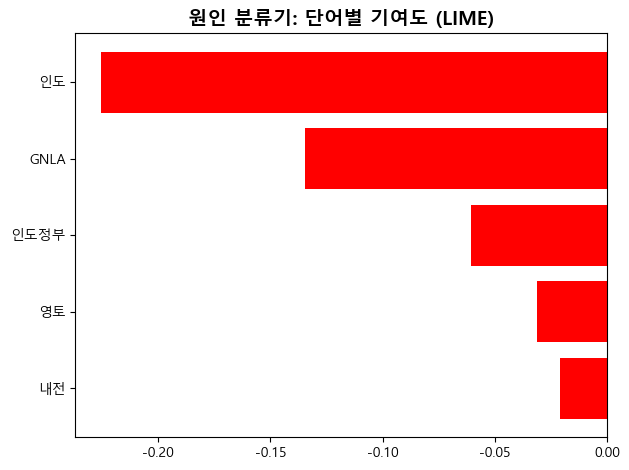

✅ LIME 시각화 저장: plots/lime_cause.png


In [ ]:
def predict_cause_proba(texts):
    """LIME용 확률 반환 함수"""
    seqs = processor.tokenizer_cause.texts_to_sequences(texts)
    pads = pad_sequences(seqs, maxlen=MAX_LEN, padding='post')
    return cause_clf_final.model.predict(pads, verbose=0)

explainer = LimeTextExplainer(
    class_names=['영토', '정부/권력', '복합']
)

# 테스트 텍스트
test_text = '인도 인도정부 GNLA 내전 영토'

exp = explainer.explain_instance(
    test_text,
    predict_cause_proba,
    num_features=10,
    num_samples=500
)

# 시각화
fig = exp.as_pyplot_figure()
plt.title('원인 분류기: 단어별 기여도 (LIME)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/lime_cause.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ LIME 시각화 저장: plots/lime_cause.png')

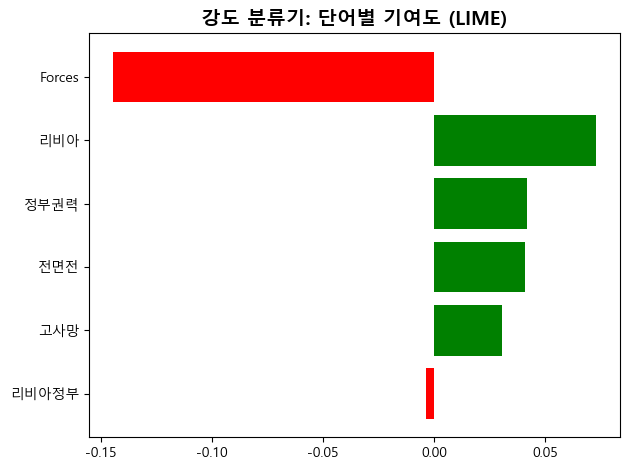

✅ LIME 시각화 저장: plots/lime_risk.png


In [ ]:
# ── 강도 분류기 LIME ──────────────────────────────────────

def predict_risk_proba(texts):
    seqs = processor.tokenizer_risk.texts_to_sequences(texts)
    pads = pad_sequences(seqs, maxlen=MAX_LEN, padding='post')
    return risk_clf_final.model.predict(pads, verbose=0)

explainer_risk = LimeTextExplainer(
    class_names=['소규모', '전면전']
)

test_text_risk = '리비아 리비아정부 Forces 정부권력 전면전 고사망'

exp_risk = explainer_risk.explain_instance(
    test_text_risk,
    predict_risk_proba,
    num_features=10,
    num_samples=500
)

fig2 = exp_risk.as_pyplot_figure()
plt.title('강도 분류기: 단어별 기여도 (LIME)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/lime_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ LIME 시각화 저장: plots/lime_risk.png')